## 1.Setup

In [93]:
# Import modules
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder  # Encoder for converting categorical variables to numeric labels
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.model_selection import StratifiedKFold  # Class for stratified K-fold cross-validation
from sklearn.metrics import roc_auc_score  # Metric function for computing ROC AUC

## 2.Load the data

### 2.1 Connect with Google Drive
To load the data, we first need to connect this Colab notebook with Google Drive.

In [94]:
# If you work with Google Colaboratory, please run this as well.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/GCI/competition"

/content/drive/MyDrive/GCI/competition


In [96]:
from pathlib import Path

PATH = Path.cwd() / "input"

train_file = PATH / "train.csv"
test_file = PATH / "test.csv"
sample_sub_file = PATH / "sample_submission.csv"

# Check if path exists
if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


In [97]:
PATH = Path.cwd() / "input"

train = pd.read_csv(PATH / "train.csv")
test = pd.read_csv(PATH / "test.csv")
sample_sub = pd.read_csv(PATH / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}")

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


In [98]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


In [99]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [100]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

## 3.Data Analysis & EDA

In [101]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [102]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


We found missing values in the following columns: **Age**,**Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone**, and **Shuttle**. We will handle these later.

### 3.2 Visualization and Analysis

Next, let's look at how many players were drafted.

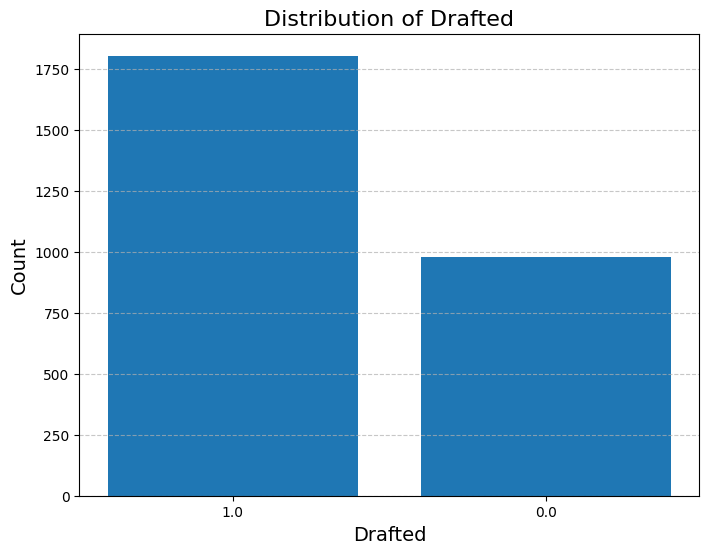

In [103]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

We can see that there are more players with **Drafted = 1** than those with **Drafted = 0**. Let's check the propotions.

In [104]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


We found that about **35%** of the players were **not drafted**, while about **65%** were **drafted**.

Next, we will continue EDA for the other features. First, let's visualize the numerical variables excluding the **"Id"** and **"Drafted"** columns.

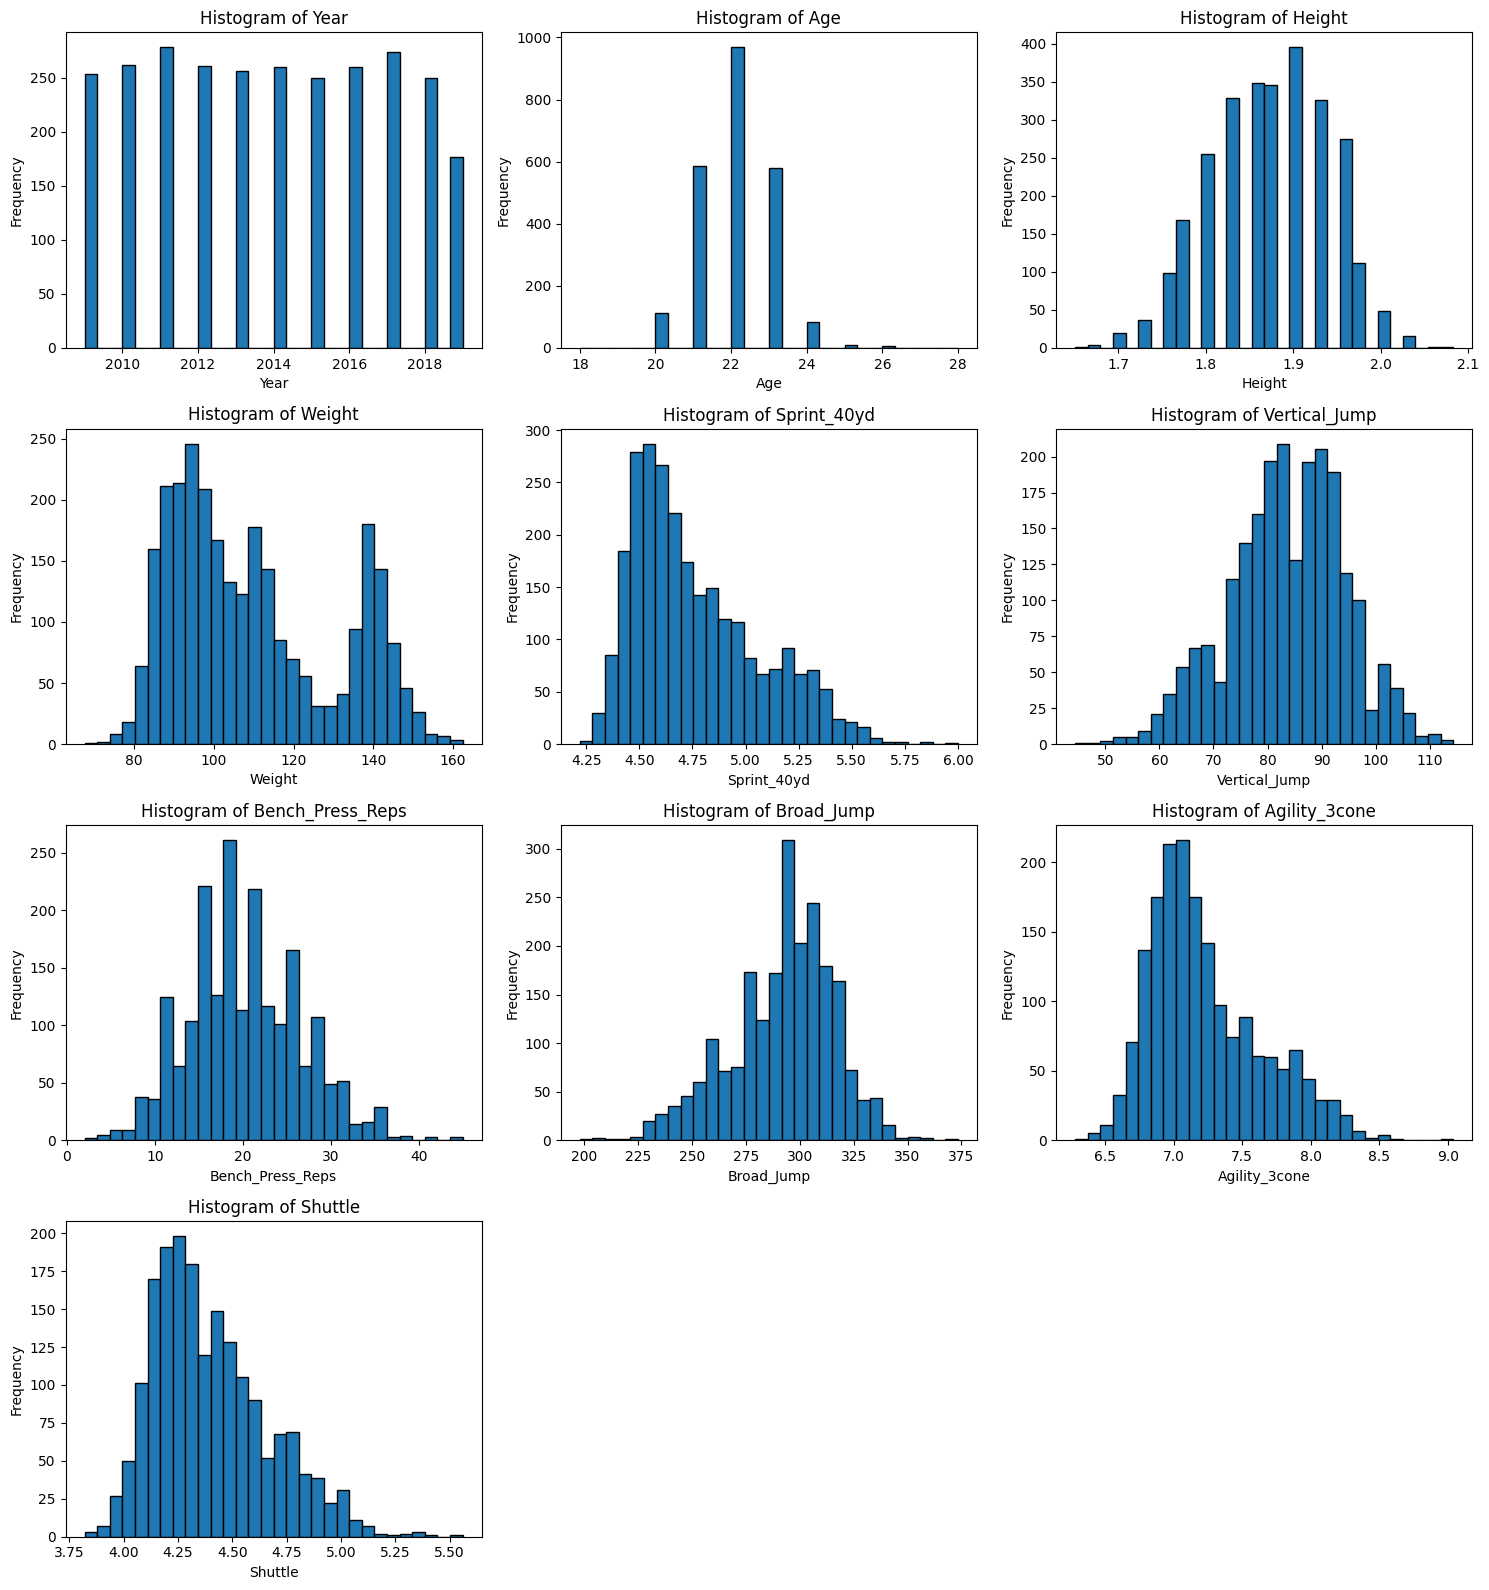

In [105]:
# Extraxt numeric columns (excluding the 'Id' and 'Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# Plot
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Let's examine the correlation matrix of the numerical features using a heatmap.

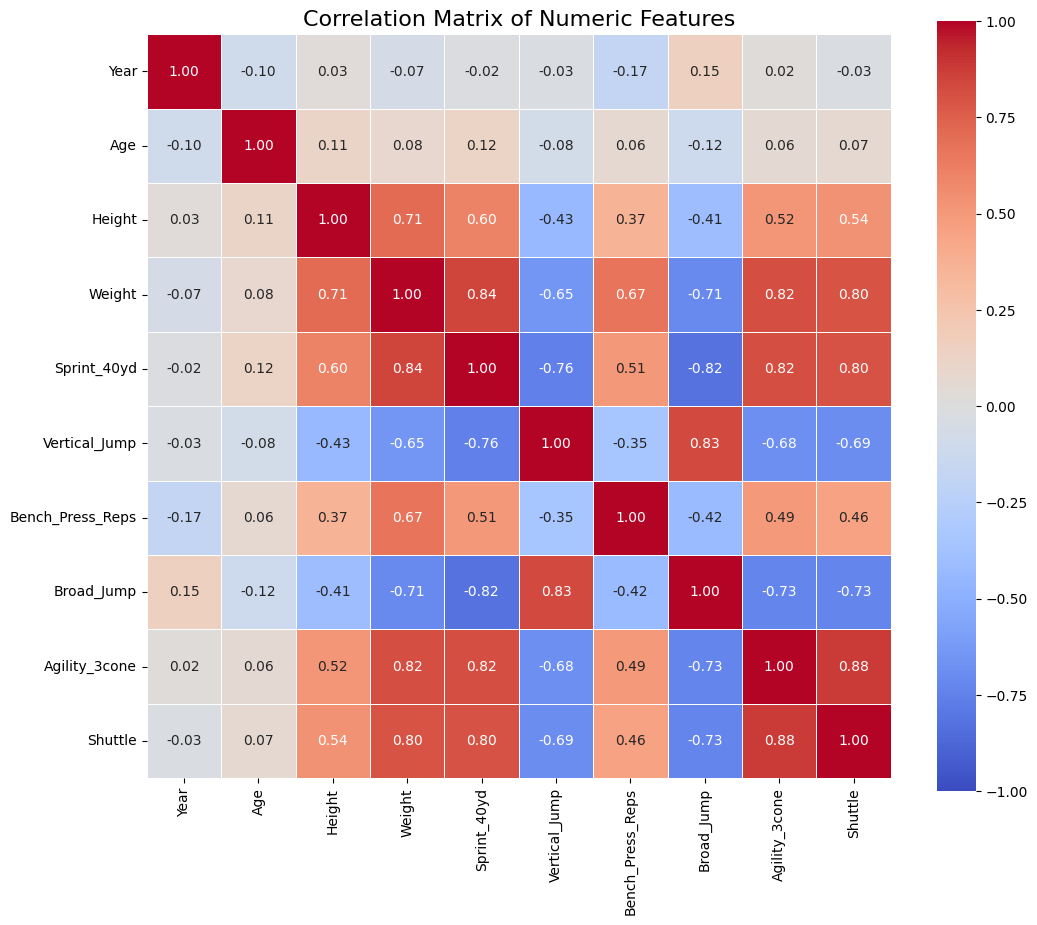

In [106]:
# Extract numeric columns (excluding the 'Id' and ''Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

The correlation coefficient between **Agility_3cone** and **Shuttle** is **0.88**, indicating a strong positive relationship. These tests may rely on similar muscle groups and movement patterns.

On the other hand, the correlation coefficient between **Sprint_40yd** and **Broad_Jump** is **-0.82**, showing a strong negative relationship. Since both events mainly depend on lower-body power, we might normally expect their scores to move together (i.e., a positive correlation), but here we observe the opposite. To investigate this further, let’s visualize **Sprint_40yd**.

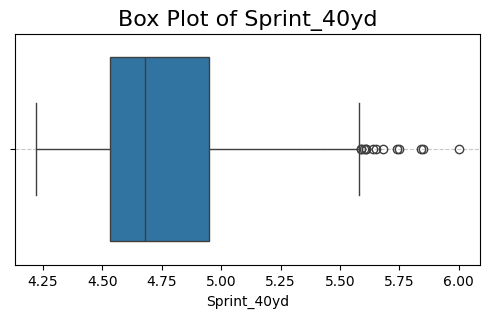

In [107]:
# Plot a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the plot, we can see that values in **Sprint_40yd** are roughly distributed between **4.25** and **6.00**. This suggests the column likely represents the **actual sprint time**, not a “score.” A median of around **4.7 seconds** is reasonable for a 40-yard (about 36-meter) dash.

In other words, **smaller values** in **Sprint_40yd** mean faster times, so **lower is better**—the opposite direction from metrics where **higher values indicate better performance**. This explains why we observed a negative correlation with **Broad_Jump**.

By visualizing the data, we were able to answer the question: **“Why is there a negative correlation?”**

Next, let's visualize the categorical features.

In [108]:
# Extract categorical features
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# Get the number of unique categories in each column
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


**'School'** has **236** unique values, which is too many to visualize clearly, so we will exclude it from the plots here.

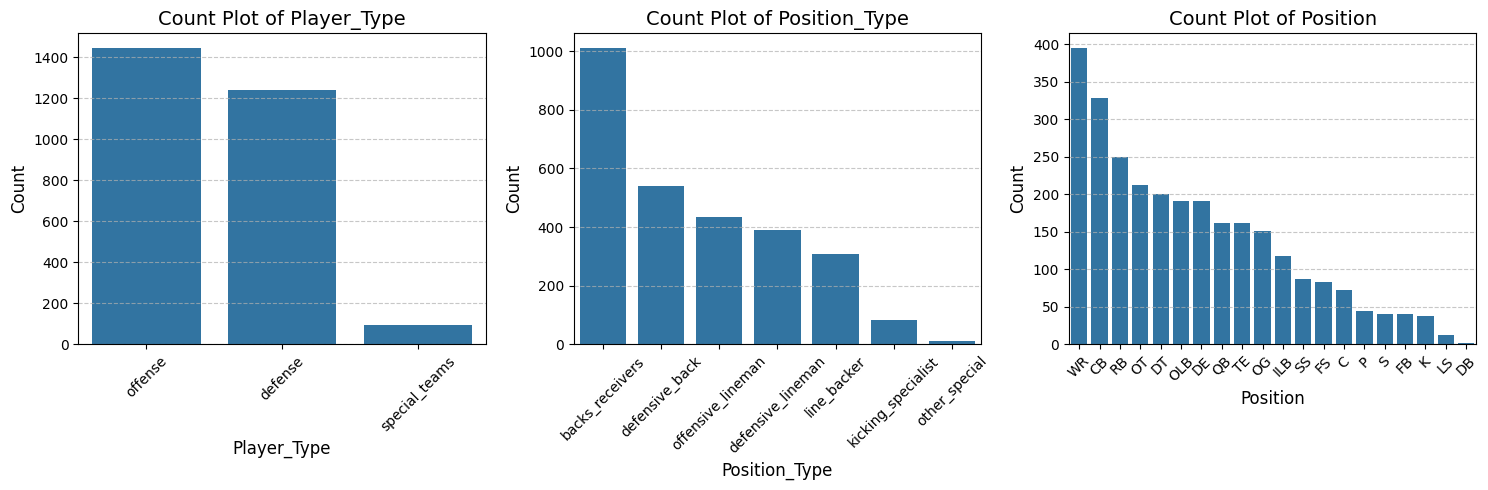

In [109]:
# Extract categorical features (object or category) and exclude the 'School' columns
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Count plots for each categorical features
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

We can see that the number of samples varies widely across categories. For example, in the **Player_Type** column, the **special_teams** category has very few samples.

Next, let's visualize the **mean value of "Drafted"** for each category level. This helps us understand, visually, which positions are more likely to be drafted.

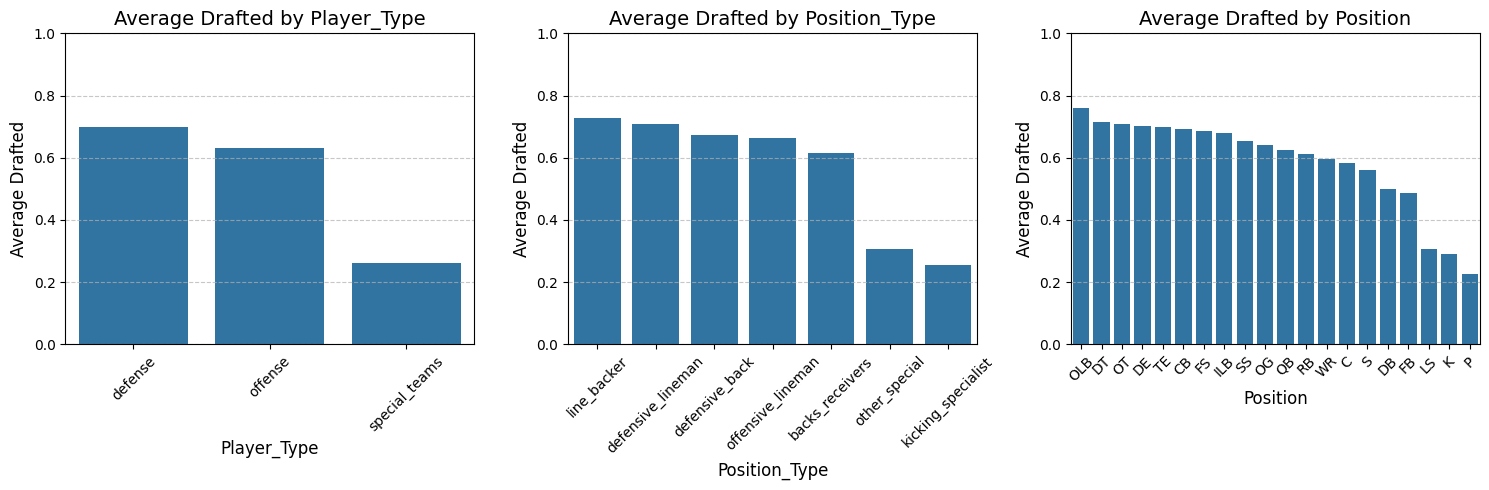

In [110]:
# Extract categorical features (object or category) and exclude the 'School' column
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot the mean value of 'Drafted' for each categorical feature as bar charts
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


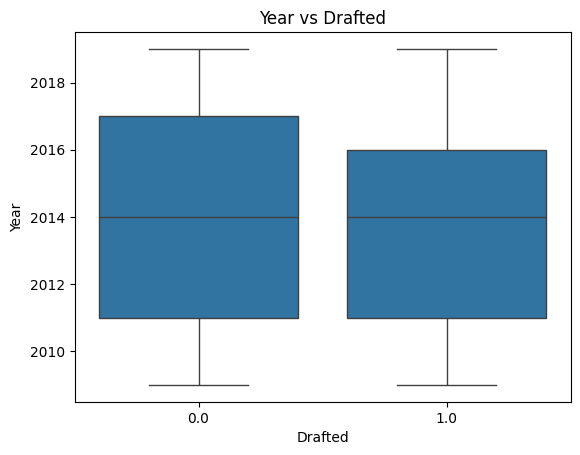

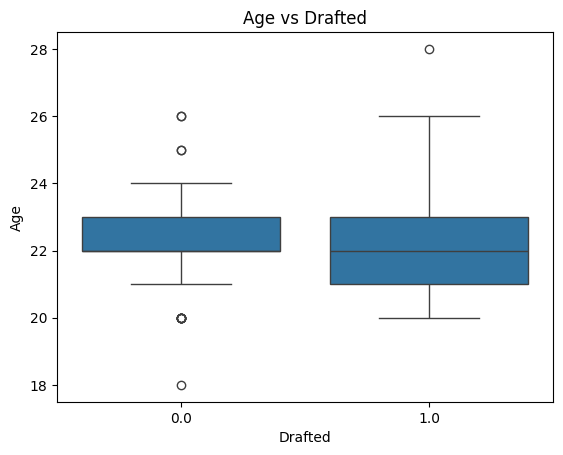

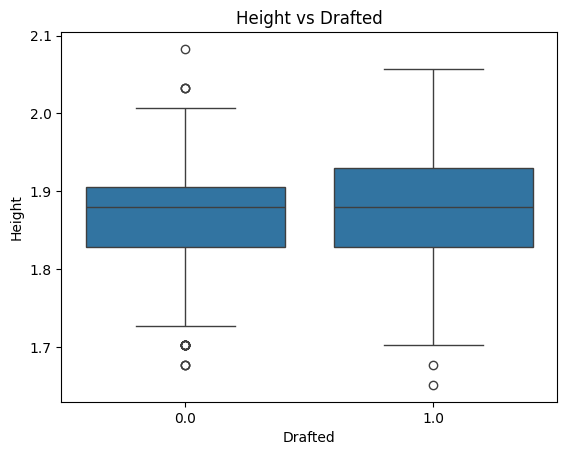

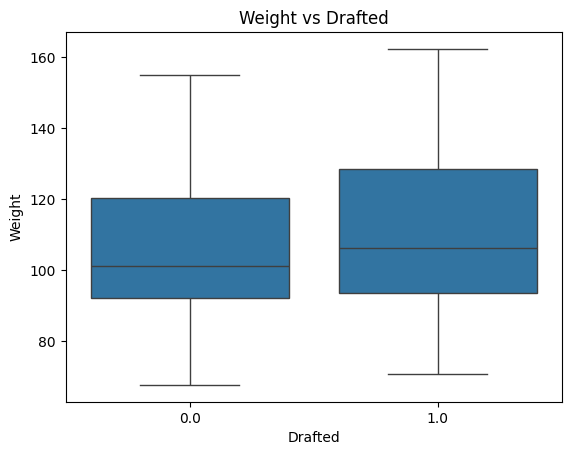

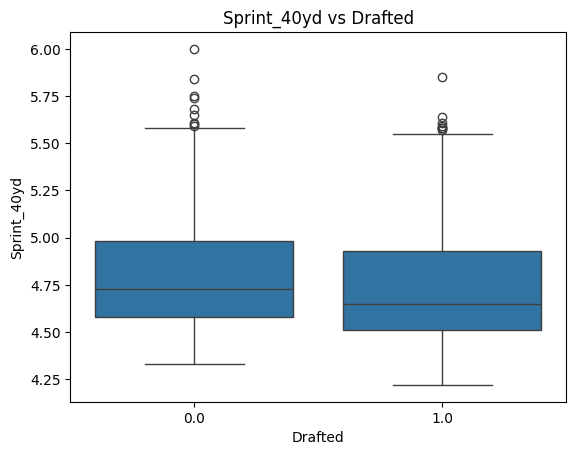

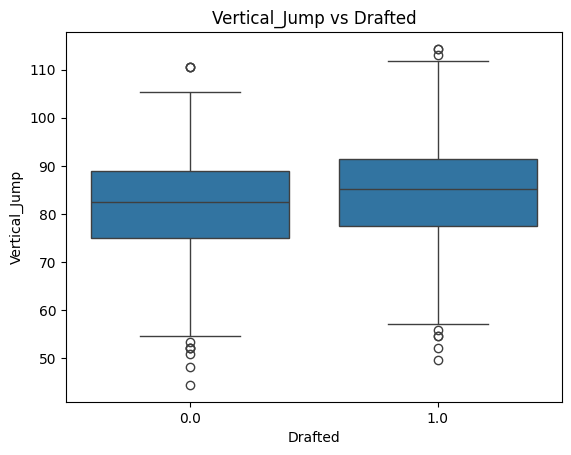

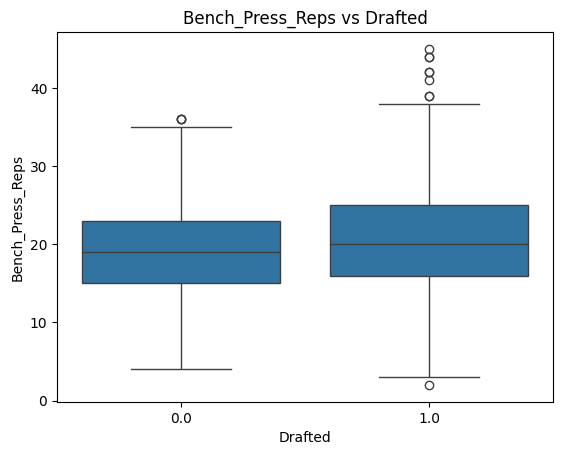

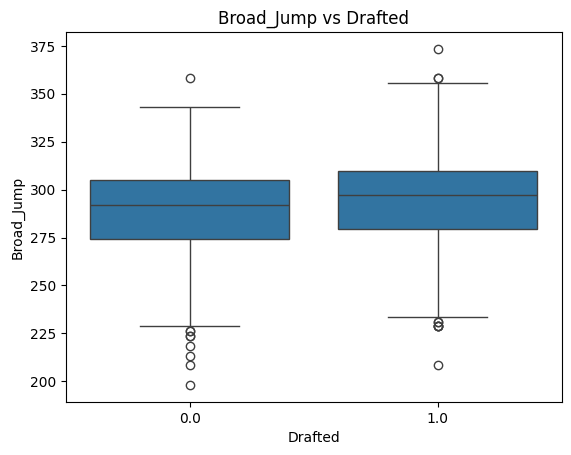

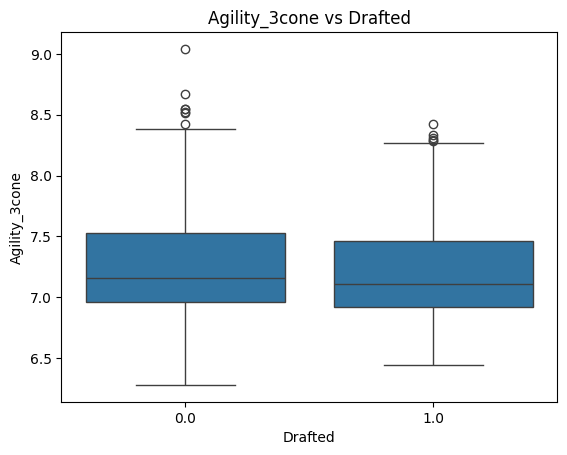

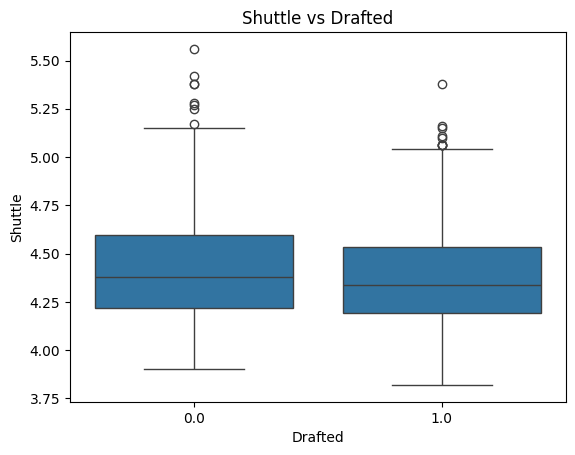

In [111]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
numerical_cols=numerical_cols.drop(['Id','Drafted'])
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=train['Drafted'], y=train[col])
    plt.title(f"{col} vs Drafted")
    plt.show()



In [112]:
# Drop unused columns
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [113]:
!pip install category_encoders
!pip install optuna

In [114]:
import optuna


In [115]:
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,OrdinalEncoder
import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer


numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = ["Position_Type", "Position","Player_Type",'School']



In [117]:
def feature_enginnering(df):
  df=df.copy()
  cat_cols=["Position_Type", "Position","Player_Type",'School']
  for col in ['Age','Sprint_40yd','Vertical_Jump','Bench_Press_Reps','Broad_Jump','Agility_3cone','Shuttle']:
    df[col+"_missings"]=df[col].isnull().astype(int)

  df["Age"] = np.log1p(df["Age"])
  df['BMI'] = df['Weight'] / (df['Height'] ** 2)
  df['size_score'] = df['Weight'] * df['Height']
  df['speed_score'] = 1 / df['Sprint_40yd']
  df['explosiveness'] = df['Vertical_Jump'] + df['Broad_Jump']
  df['agility'] = (df['Agility_3cone'] + df['Shuttle']) / 2
  df['athletic_score'] = (
    df['speed_score'] +
    df['explosiveness'] +
    df['Bench_Press_Reps']) / 3
  df['athletic_efficiency'] = df['athletic_score'] / df['Age']
  df["power_speed"] = df["Bench_Press_Reps"] / df["Sprint_40yd"]
  df["jump_power"] = df["Broad_Jump"] * df["Weight"]
  for col in cat_cols:
      df[col] = df[col].astype("category")
  freq = train['School'].value_counts()

  df['School_freq'] = df['School'].map(freq)

  df['speed_vs_position'] = (
    df.groupby('Position')['Sprint_40yd']
      .transform(lambda x: x.rank(pct=True))
)
  df=df.drop(columns=['School'])


  return df


In [118]:
X=feature_enginnering(X)
test=feature_enginnering(test)

/tmp/ipykernel_17838/1868323123.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Position')['Sprint_40yd']
/tmp/ipykernel_17838/1868323123.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Position')['Sprint_40yd']


# **XGBoost**

In [ ]:
from xgboost import XGBClassifier

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators",200, 800)

    max_depth = trial.suggest_int("max_depth",3,10)

    learning_rate = trial.suggest_float("learning_rate", 0.01,0.3,log=True)

    subsample = trial.suggest_float("subsample",0.5,1.0)

    colsample_bytree = trial.suggest_float("colsample_bytree",0.5,1.0)

    gamma = trial.suggest_float(
        "gamma",1e-8,10,log=True
    )

    min_child_weight = trial.suggest_int(
        "min_child_weight",1,10
    )
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10, log=True)

    reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10, log=True)



    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    aucs = []



    for train_idx, val_idx in skf.split(X, y):


        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]






        model_xg = XGBClassifier(
            booster="gbtree",
            n_jobs=-1,
            random_state=42,

            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,

            subsample=subsample,
            colsample_bytree=colsample_bytree,
            scale_pos_weight=1,

            gamma=gamma,
            min_child_weight=min_child_weight,

            eval_metric="auc",
            enable_categorical=True
        )

        model_xg.fit(
            X_train,
            y_train
        )



        preds = model_xg.predict_proba(X_val)[:, 1]


        auc = roc_auc_score(
            y_val,
            preds
        )

        aucs.append(auc)


    return np.mean(aucs)

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

In [ ]:
print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)

In [119]:
model_xg = XGBClassifier(
    booster="gbtree",
    random_state=42,
    n_jobs=-1,
    n_estimators=236,
    max_depth=6,
    learning_rate=0.013057835229587051,

    subsample=0.5207225291542101,
    colsample_bytree=0.640305392147341,

    gamma=0.7492373025580945,
    min_child_weight=9,

    reg_alpha=0.013578006388814859,
    reg_lambda=1.7440639439384198e-07,
    enable_categorical=True,

    eval_metric="auc"
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []


for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X .iloc[train_idx], X .iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]


    model_xg.fit(X_train, y_train)


    y_valid_pred_proba = model_xg.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")


mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4)) #0.8308



Fold 1
  AUC: 0.807
Fold 2
  AUC: 0.8678
Fold 3
  AUC: 0.8647
Fold 4
  AUC: 0.79
Fold 5
  AUC: 0.8459

Average Validation AUC: 0.8351


# **LightBoost**

In [ ]:
from lightgbm import LGBMClassifier


In [120]:
cat_cols = ["Position_Type", "Position","Player_Type"]

In [ ]:

def objective(trial):


    # Model params
    n_estimators = trial.suggest_int("n_estimators", 300, 600)
    num_leaves = trial.suggest_int("num_leaves",5,40)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate=trial.suggest_float("learning_rate",0.01,0.3,log=True)
    subsample=trial.suggest_float("subsample",0.5,1)
    colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1)
    min_child_samples=trial.suggest_int("min_child_samples",10,60)

    reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 10, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 10, log=True)

    min_split_gain = trial.suggest_float("min_split_gain", 0.0, 1.0)

    subsample_freq = trial.suggest_int("subsample_freq", 1, 10)

    min_child_weight = trial.suggest_float("min_child_weight", 1e-3, 10, log=True)

    max_bin = trial.suggest_int("max_bin", 100, 500)

    path_smooth = trial.suggest_float("path_smooth", 0.0, 10.0)

    feature_fraction_bynode = trial.suggest_float(
        "feature_fraction_bynode", 0.5, 1.0
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in skf.split(X, y):

        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model_lg=LGBMClassifier(boosting_type="gbdt",n_jobs=-1,random_state=42,n_estimators=n_estimators,num_leaves=num_leaves,
                             max_depth=max_depth,learning_rate=learning_rate,subsample=subsample,colsample_bytree=colsample_bytree,
                             min_child_samples=min_child_samples,min_split_gain=min_split_gain,reg_alpha=reg_alpha,reg_lambda=reg_lambda,
                             subsample_freq=subsample_freq,min_child_weight=min_child_weight,max_bin=max_bin,path_smooth=path_smooth,
                             feature_fraction_bynode=feature_fraction_bynode)


        model_lg.fit(X_train, y_train,categorical_feature=True)

        preds = model_lg.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, preds))

    return np.mean(aucs)

In [ ]:
study_lg = optuna.create_study(direction="maximize")
study_lg.optimize(objective, n_trials=30)

In [ ]:
print("Best AUC:", study_lg.best_value)
print("Best Params:", study_lg.best_params)

In [121]:

model_lg=LGBMClassifier(boosting_type="gbdt",n_jobs=-1,random_state=42,n_estimators=415,
                        num_leaves=9,
                        max_depth=4,learning_rate=0.05831926131943834,
                        subsample=0.5132937967138491,
                        colsample_bytree=0.7519337465087628,
                        min_child_samples=37,reg_alpha=3.639971932782144,
                        reg_lambda=0.0489095513179101,min_split_gain= 0.6669540339242507,
                        subsample_freq=2,min_child_weight=0.06895711886921439,
                        max_bin=368,path_smooth=1.2452781820532544,
                        feature_fraction_bynode=0.5715182569529864,
                        verbose=0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


auc_scores = []


for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]


    model_lg.fit(X_train, y_train,categorical_feature=cat_cols)


    y_valid_pred_proba = model_lg.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")


mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Average Validation AUC: 0.8314


# **CatBoost**

In [122]:
!pip install catboost

In [134]:
from catboost import CatBoostClassifier

In [ ]:
def objective(trial):
  cat_cols = ["Position_Type", "Position", "Player_Type"]



  params = {
        "iterations": trial.suggest_int("iterations", 300, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),

        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10, log=True),

        "random_strength": trial.suggest_float("random_strength", 1e-3, 10, log=True),

        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 10),

        "border_count": trial.suggest_int("border_count", 32, 255),

        "rsm": trial.suggest_float(
            "rsm",
            0.5,
            1.0
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "min_data_in_leaf": trial.suggest_int(
            "min_data_in_leaf",
            10,
            100
        ),


        "random_seed": 42,
        "loss_function": "Logloss",
        "eval_metric": "AUC",

        "verbose": 0
    }

  skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

  auc_scores = []

  for train_idx, valid_idx in skf.split(X, y):

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostClassifier(**params)

        model.fit(
            X_train,
            y_train,
            cat_features=cat_cols,
            eval_set=(X_valid, y_valid),
            use_best_model=True,
            early_stopping_rounds=100
        )

        y_pred = model.predict_proba(X_valid)[:, 1]

        auc = roc_auc_score(y_valid, y_pred)

        auc_scores.append(auc)

  return np.mean(auc_scores)




In [ ]:
study_cat = optuna.create_study(
    direction="maximize"
)

study_cat.optimize(
    objective,
    n_trials=30
)

print("Best AUC:", study_cat.best_value)
print("\nBest Params:")
print(study_cat.best_params)

In [124]:

model_c = CatBoostClassifier(
            learning_rate= 0.054531941091170204,
            l2_leaf_reg=0.908978978076615,
            iterations=1772,
            random_strength=1.8779760972021968,
            bagging_temperature=0.36141238211178106,
            depth=5,
            min_data_in_leaf=99,
            subsample=0.9940011453375848,
            rsm=0.8378135224635619,
            border_count=226,
            random_state=42,
            loss_function="Logloss",
            verbose=0,
            eval_metric="AUC",
            cat_features=cat_cols

        )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


auc_scores = []


for fold, (train_idx, valid_idx) in enumerate(skf.split(X , y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X .iloc[train_idx], X .iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]


    model_c.fit(X_train, y_train)


    y_valid_pred_proba = model_c.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")


mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))



Fold 1
  AUC: 0.8057
Fold 2
  AUC: 0.8366
Fold 3
  AUC: 0.8251
Fold 4
  AUC: 0.7821
Fold 5
  AUC: 0.8313

Average Validation AUC: 0.8162


# **Meta Model**

In [125]:
from sklearn.linear_model import LogisticRegression

oof_pred_xg = np.zeros(len(X))
oof_pred_lg = np.zeros(len(X))
oof_pred_c  = np.zeros(len(X))


test_pred_xg_list = []
test_pred_lg_list = []
test_pred_c_list  = []


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Starting OOF Generation ---")
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"\nTraining Fold {fold + 1}...")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]


    model_xg.fit(X_train, y_train)
    oof_pred_xg[valid_idx] = model_xg.predict_proba(X_valid)[:, 1]
    test_pred_xg_list.append(model_xg.predict_proba(test)[:, 1])


    model_lg.fit(X_train, y_train, categorical_feature=cat_cols)
    oof_pred_lg[valid_idx] = model_lg.predict_proba(X_valid)[:, 1]
    test_pred_lg_list.append(model_lg.predict_proba(test)[:, 1])


    model_c.fit(X_train, y_train)
    oof_pred_c[valid_idx] = model_c.predict_proba(X_valid)[:, 1]
    test_pred_c_list.append(model_c.predict_proba(test)[:, 1])


    fold_auc_c = roc_auc_score(y_valid, oof_pred_c[valid_idx])
    print(f"Fold {fold + 1} CatBoost Validation AUC: {fold_auc_c:.4f}")

print("\n--- Out-of-Fold Generation Complete ---")

--- Starting OOF Generation ---


--- Out-of-Fold Generation Complete ---


In [126]:
print(f"Overall XGBoost OOF AUC:  {roc_auc_score(y, oof_pred_xg):.4f}")
print(f"Overall LightGBM OOF AUC: {roc_auc_score(y, oof_pred_lg):.4f}")
print(f"Overall CatBoost OOF AUC: {roc_auc_score(y, oof_pred_c):.4f}")

X_meta = pd.DataFrame({
    'xg_preds': oof_pred_xg,
    'lg_preds': oof_pred_lg,
    'c_preds':  oof_pred_c
})

X_test_meta = pd.DataFrame({
    'xg_preds': np.mean(test_pred_xg_list, axis=0),
    'lg_preds': np.mean(test_pred_lg_list, axis=0),
    'c_preds':  np.mean(test_pred_c_list, axis=0)
})

Overall XGBoost OOF AUC:  0.8335
Overall LightGBM OOF AUC: 0.8305
Overall CatBoost OOF AUC: 0.8150


In [127]:
weights = [
    (0.7, 0.2, 0.1),
    (0.8, 0.1, 0.1),
    (0.8, 0.1, 0.5),
    (0.9, 0.1, 0.5),

    (0.75, 0.25, 0.0),
    (0.65, 0.35, 0.0),
    (0.6, 0.3, 0.1),
    (0.6, 0.25, 0.15),
    (0.7,0.5,0.6),


]

for w_lg, w_cat, w_xg in weights:

    blend = (
        w_lg * oof_pred_lg +
        w_cat * oof_pred_c +
        w_xg * oof_pred_xg
    )

    auc = roc_auc_score(y, blend)

    print(
        f"LGB:{w_lg} CAT:{w_cat} XGB:{w_xg}"
        f" --> AUC: {auc:.5f}"
    )

LGB:0.7 CAT:0.2 XGB:0.1 --> AUC: 0.83128
LGB:0.8 CAT:0.1 XGB:0.1 --> AUC: 0.83145
LGB:0.8 CAT:0.1 XGB:0.5 --> AUC: 0.83301
LGB:0.9 CAT:0.1 XGB:0.5 --> AUC: 0.83289
LGB:0.75 CAT:0.25 XGB:0.0 --> AUC: 0.83043
LGB:0.65 CAT:0.35 XGB:0.0 --> AUC: 0.82972
LGB:0.6 CAT:0.3 XGB:0.1 --> AUC: 0.83071
LGB:0.6 CAT:0.25 XGB:0.15 --> AUC: 0.83128
LGB:0.7 CAT:0.5 XGB:0.6 --> AUC: 0.83200


In [128]:
blend_pred = (
    0.8 * oof_pred_lg +
    0.1 * oof_pred_c +
    0.1 * oof_pred_xg
)

print("Blend AUC:", roc_auc_score(y, blend_pred))

Blend AUC: 0.8314533718512772


In [129]:
test_blend = (
    0.8 * np.mean(test_pred_lg_list, axis=0) +
    0.1 * np.mean(test_pred_c_list, axis=0) +
    0.1 * np.mean(test_pred_xg_list, axis=0)
)

In [130]:
submission = pd.read_csv(PATH / "sample_submission.csv")

submission["Drafted"] = test_blend

submission.to_csv(PATH / "blend_submission_the_best.csv", index=False)

print("Submission saved!")

Submission saved!
